In [1]:
import torch
import numpy as np

from mlp import MLP

from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning

tkwargs = {
    'dtype': torch.float64,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

REFERENCE = torch.tensor([-0.1, 0.0], **tkwargs)

# In this notebook we sample the 8M space exhaustively and use the NN surrogate 
# to determine the maximum HV of the pareto frontier.
# This should show us how limited we are in the 0.5 increment constrained case.

In [2]:
# Create then NN model and load the saved weights
mdl = MLP().to(**tkwargs)
mdl.load_state_dict(torch.load('models/surrogate.pth', weights_only=True))
mdl.eval()

# Create the objective functions
def func1(X):
    # Utilize the MLP surrogate to predict viability
    return mdl.predict(X)

def func2(X):
    # Sum the individual concentrations to a total concentration
    return X.sum(axis = 1).reshape(-1, 1)

def multi_objective(X):
    return torch.cat([func1(X), func2(X)], dim=1)

In [3]:
# What is the HV of the initial points we sampled?
data = torch.Tensor(np.load('data/data_initial.npy')[:,:-2]).to(**tkwargs)
pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'Initial: HV = {hv.item():.5f}')

Initial: HV = 434.81732


In [4]:
# What is the HV of the initial points we sampled?
data = torch.Tensor(np.load('data/data_initial.npy')[:,:-2]).to(**tkwargs)
iter1 = torch.Tensor(np.load('data/data_iter1.npy')[:,:-2]).to(**tkwargs)
data = torch.cat([data, iter1])
print(data.shape)
pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'Initial + Iter1: HV = {hv.item():.5f}')

torch.Size([620, 7])
Initial + Iter1: HV = 511.08504


In [5]:
# What is the HV of the initial points we sampled?
data = torch.Tensor(np.load('data/data_initial.npy')[:,:-2]).to(**tkwargs)
iter1 = torch.Tensor(np.load('data/data_iter1.npy')[:,:-2]).to(**tkwargs)
iter2 = torch.Tensor(np.load('data/data_iter2.npy')[:,:-2]).to(**tkwargs)
data = torch.cat([data, iter1, iter2])
print(data.shape)
pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'Initial + Iter1 + Iter2: HV = {hv.item():.5f}')

torch.Size([662, 7])
Initial + Iter1 + Iter2: HV = 511.08504


In [6]:
# Sample the feature space exhaustively to determine the maximum HV of the pareto frontier
maximum = 6
data = torch.load(f'data/combinations-{maximum}M.pt').to(**tkwargs)

pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'{maximum}M: HV = {hv.item():.5f}')

6M: HV = 520.56211


In [7]:
# Sample the feature space exhaustively to determine the maximum HV of the pareto frontier
maximum = 8
data = torch.load(f'data/combinations-{maximum}M.pt').to(**tkwargs)

pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'{maximum}M: HV = {hv.item():.5f}')

8M: HV = 669.65570


In [8]:
# Sample the feature space exhaustively to determine the maximum HV of the pareto frontier
maximum = 10
data = torch.load(f'data/combinations-{maximum}M.pt').to(**tkwargs)

pred = multi_objective(data)
hv = FastNondominatedPartitioning(ref_point = REFERENCE, Y = pred).compute_hypervolume()
print(f'{maximum}M: HV = {hv.item():.5f}')

10M: HV = 792.42229


In [ ]:
import matplotlib.pyplot as plt

def loadData():
    data = torch.tensor(np.load('data/data_initial.npy')).to(**tkwargs)
    iter1 = torch.tensor(np.load('data/data_iter1.npy')).to(**tkwargs)
    iter2 = torch.tensor(np.load('data/data_iter2.npy')).to(**tkwargs)
    return torch.cat([data, iter1, iter2], dim=0)

def loadVarData():
    data = torch.tensor(np.load('data/data_all.npy)')).to(**tkwargs)

def plot_pareto(ax, conc):
    data = torch.load(f'data/combinations-{conc}M.pt').to(**tkwargs)
    Y_pred = multi_objective(data)
    # Append the true experimental data
    Y_exp = torch.flip(loadData()[:,-2:], dims = [1])
    Y = torch.cat([Y_pred, Y_exp], dim=0)
    partitioning = FastNondominatedPartitioning(ref_point=REFERENCE, Y=Y)
    pareto_Y = partitioning.pareto_Y

    # Plot the Pareto front
    # for j, y in enumerate(Y):
    ax.scatter(Y[:, 1].cpu(), Y[:, 0].cpu(), color = 'black', alpha = 0.5)
    ax.scatter(pareto_Y[:, 1].cpu(), pareto_Y[:, 0].cpu(), color='red', label='Pareto Front')
    ax.set_title(f'{conc}M, Hypervolume: {FastNondominatedPartitioning(ref_point = REFERENCE, Y = Y).compute_hypervolume():.5f}')
    ax.set_xlabel('Total Concentration')
    ax.set_ylabel('% Viability')
    ax.grid()

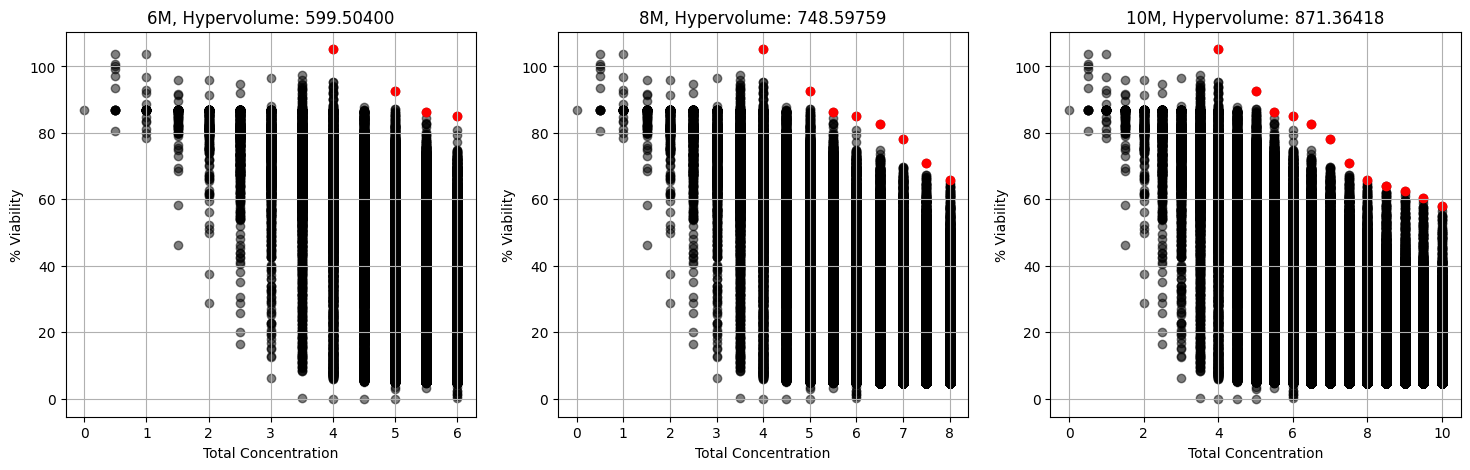

In [23]:
fig = plt.figure(figsize = (18,5))
ax = fig.subplots(1, 3)

plot_pareto(ax[0], 6)
plot_pareto(ax[1], 8)
plot_pareto(ax[2], 10)